<a href="https://colab.research.google.com/github/JacekSkrzeszewski/bigdata2026/blob/main/Skrzeszewski_dokumentacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pytania**


1.   Jakie jest powiązanie pomiędzy poziomem wykształcenia (education_level) a wysokością rocznego wynagrodzenia (annual_salary_usd)?
2.   Czy istnieje zależność między pracą zdalną (remote_work) a oceną wyników (performance_score)?
3.   W jaki sposób wielkość miasta (city tier) wpływa na zarobki w opisanej grupie?




**Tworzenie tabel znormalizowanych**

Model Płatka Śniegu (Snowflake Schema) to wielowymiarowy model danych. Jego tabele wymiarów (Dimension
Tables) są znormalizowane. Oznacza to, że dane w wymiarach są rozbite na dodatkowe, powiązane ze sobą
tabele, co zmniejsza redundancję (powtarzanie się danych) i oszczędza miejsce, ale może wymagać bardziej
skomplikowanych złączeń (JOIN) podczas odpytywania bazy. W centrum zawsze znajduje się Tabela Faktów
(Fact Table) przechowująca mierzalne dane liczbowe i klucze obce do wymiarów.

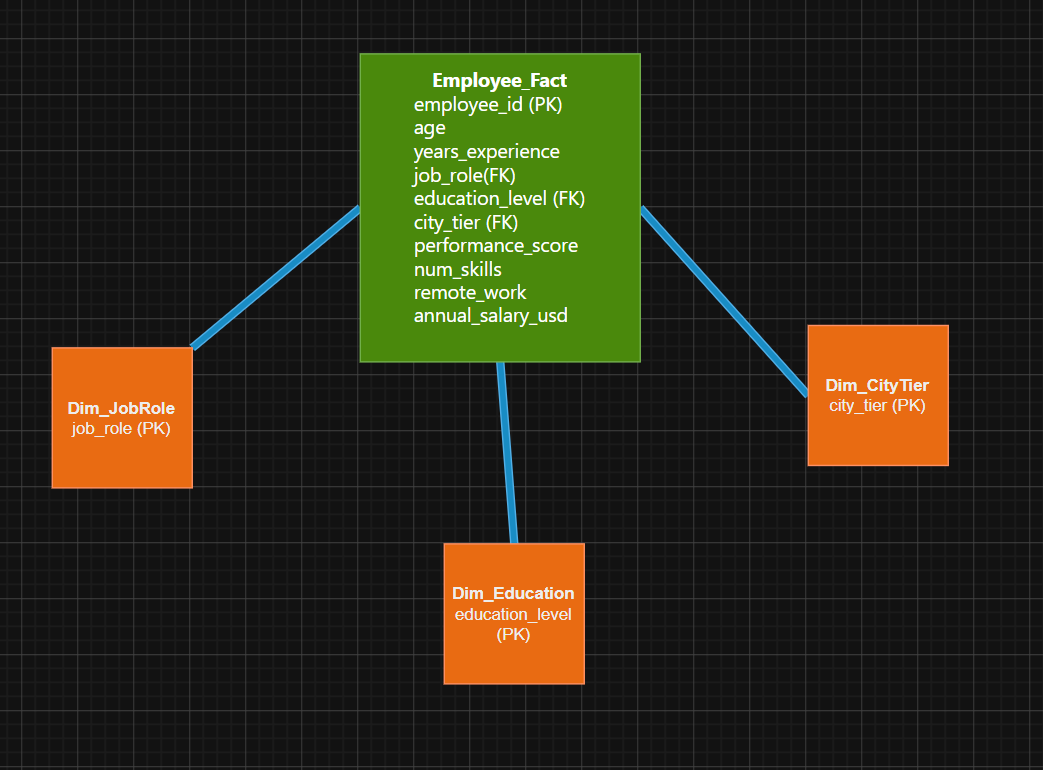

In [ ]:
-- 1. Tworzenie tabel wymiarów (Dimension Tables)
CREATE TABLE Dim_JobRole (
    job_role VARCHAR(100) PRIMARY KEY
);

CREATE TABLE Dim_Education (
    education_level VARCHAR(50) PRIMARY KEY
);

CREATE TABLE Dim_CityTier (
    city_tier INT PRIMARY KEY
);

-- 2. Tworzenie tabeli faktów (Fact Table) z kluczami obcymi (Foreign Keys)
CREATE TABLE Employee_Fact (
    employee_id VARCHAR(20) PRIMARY KEY,
    age INT,
    years_experience INT,
    performance_score DECIMAL(3,1),
    num_skills INT,
    remote_work BOOLEAN,
    annual_salary_usd DECIMAL(10,2),

    -- Klucze obce (Foreign Keys)
    job_role VARCHAR(100),
    education_level VARCHAR(50),
    city_tier INT,

    FOREIGN KEY (job_role) REFERENCES Dim_JobRole(job_role),
    FOREIGN KEY (education_level) REFERENCES Dim_Education(education_level),
    FOREIGN KEY (city_tier) REFERENCES Dim_CityTier(city_tier)
);

**Oczyszczanie danych**

Wynik flow: plik Skrzeszewski_output.hyper

Kroki: plik Skrzeszewski_kroki.tflx

1.   Program Tableau Prep dodał kolumnę z numeracją wierszy oraz ustawił typ kolumny **annual_salary_usd** jako **Number (decimal)** w wyniku czego w pierwszej komórce tej kolumny pojawiła się wartość null.
Usunąłem kolumnę z numeracją, zmieniłem typ kolumny **annual_salary_usd** na **String**
2.   W kolumnie **education_level** wartości **PhD** zostały podmienione na wartości **4**. Naprawiłem to.
3.   W części komórek kolumny **employee_id** zmieniono format numeracji z
**"EMP000X"** na **"EMPX"**.
Dodałem brakujące zera.
4.   W pierwszej komórce kolumny **annual_salary_usd** pojawiła się wartość **"106343point31"** zamiast poprawnej wartości **"106343.31"**. Poprawiłem ją na właściwą oraz przywróciłem wcześniej zmieniony przeze mnie typ kolumny na **Number (decimal)**.

Po wyeliminowaniu wszystkich celowych błędów, dane zostały przygotowane do wizualizacji poprzez weryfikację i przypisanie właściwych typów zmiennych
(zmiana typu kolumny **annual_salary_usd** na **Number (decimal)** po usunięciu błędu tekstowego, zmiana typów kolumn **city_tier** i **remote_work** na **String**). Oczyszczony strumień (flow) został zakończony krokiem Output, a następnie wyeksportowany do formatu Tableau Extract (.hyper).



**Wizualizacja danych**

Po wgraniu pliku Skrzeszewski_output.hyper do Tableau Desktop przy **city_tier** pojawiła się ikona globusa, zmieniłem **Geographic Role** na **None**.

1.   W pierwszym arkuszu odpowiadającym na pytanie "Jakie jest powiązanie pomiędzy poziomem wykształcenia (education_level) a wysokością rocznego wynagrodzenia (annual_salary_usd)?" umieściłem **education_level** w colums i **annual_salary_usd** w rows. W **education_level** poszczególne poziomy były wyświetlane w kolejności alfabetycznej, manualnie zamieniłem **High School** i **Bachelor** miejscami, aby zwiększyć przejrzystość tworzonego wykresu. W **annual_salary_usd** zmieniłem sumę na średnią.

2.   W drugim arkuszu odpowiadającym na pytanie "Czy istnieje zależność między pracą zdalną (remote_work) a oceną wyników (performance_score)?" umieściłem **remote_work** w colums i **performance_score** w rows. W **remote_work** dodałem aliasy **Praca stacjonarna** dla wartości **0** i **Praca zdalna** dla wartości **1**. W **performance_score** zmieniłem sumę na średnią.

3.   W trzecim arkuszu odpowiadającym na pytanie "W jaki sposób wielkość miasta (city tier) wpływa na zarobki w opisanej grupie?" umieściłem **city_tier** w colums i **annual_salary_usd** w rows. W **city_tier* dodałem aliasy **Duże miasto** dla wartości **1**, **Średnie miasto** dla wartości **2** oraz **Małe miasto** dla wartości **3**, następnie manualnie poprawiłem zaburzoną przez to kolejność. W **annual_salary_usd** zmieniłem sumę na średnią.

**Elementy interkatywne**


1.   Dodałem możliwość użycia każdego wykresów jako filtra. Po kliknięciu na dowolny słupek na każdym z trzech wykresów dane na pozostałych są zawężane do wybranej grupy np. klikając na słupek **Praca zdalna** można porównać zarobki w zależności od wykształcenia wyłącznie dla osób pracujących zdalnie.
2.   Dodałem możliwość zawężenia do konkretnego stanowiska/stanowisk (panel po prawej stronie)

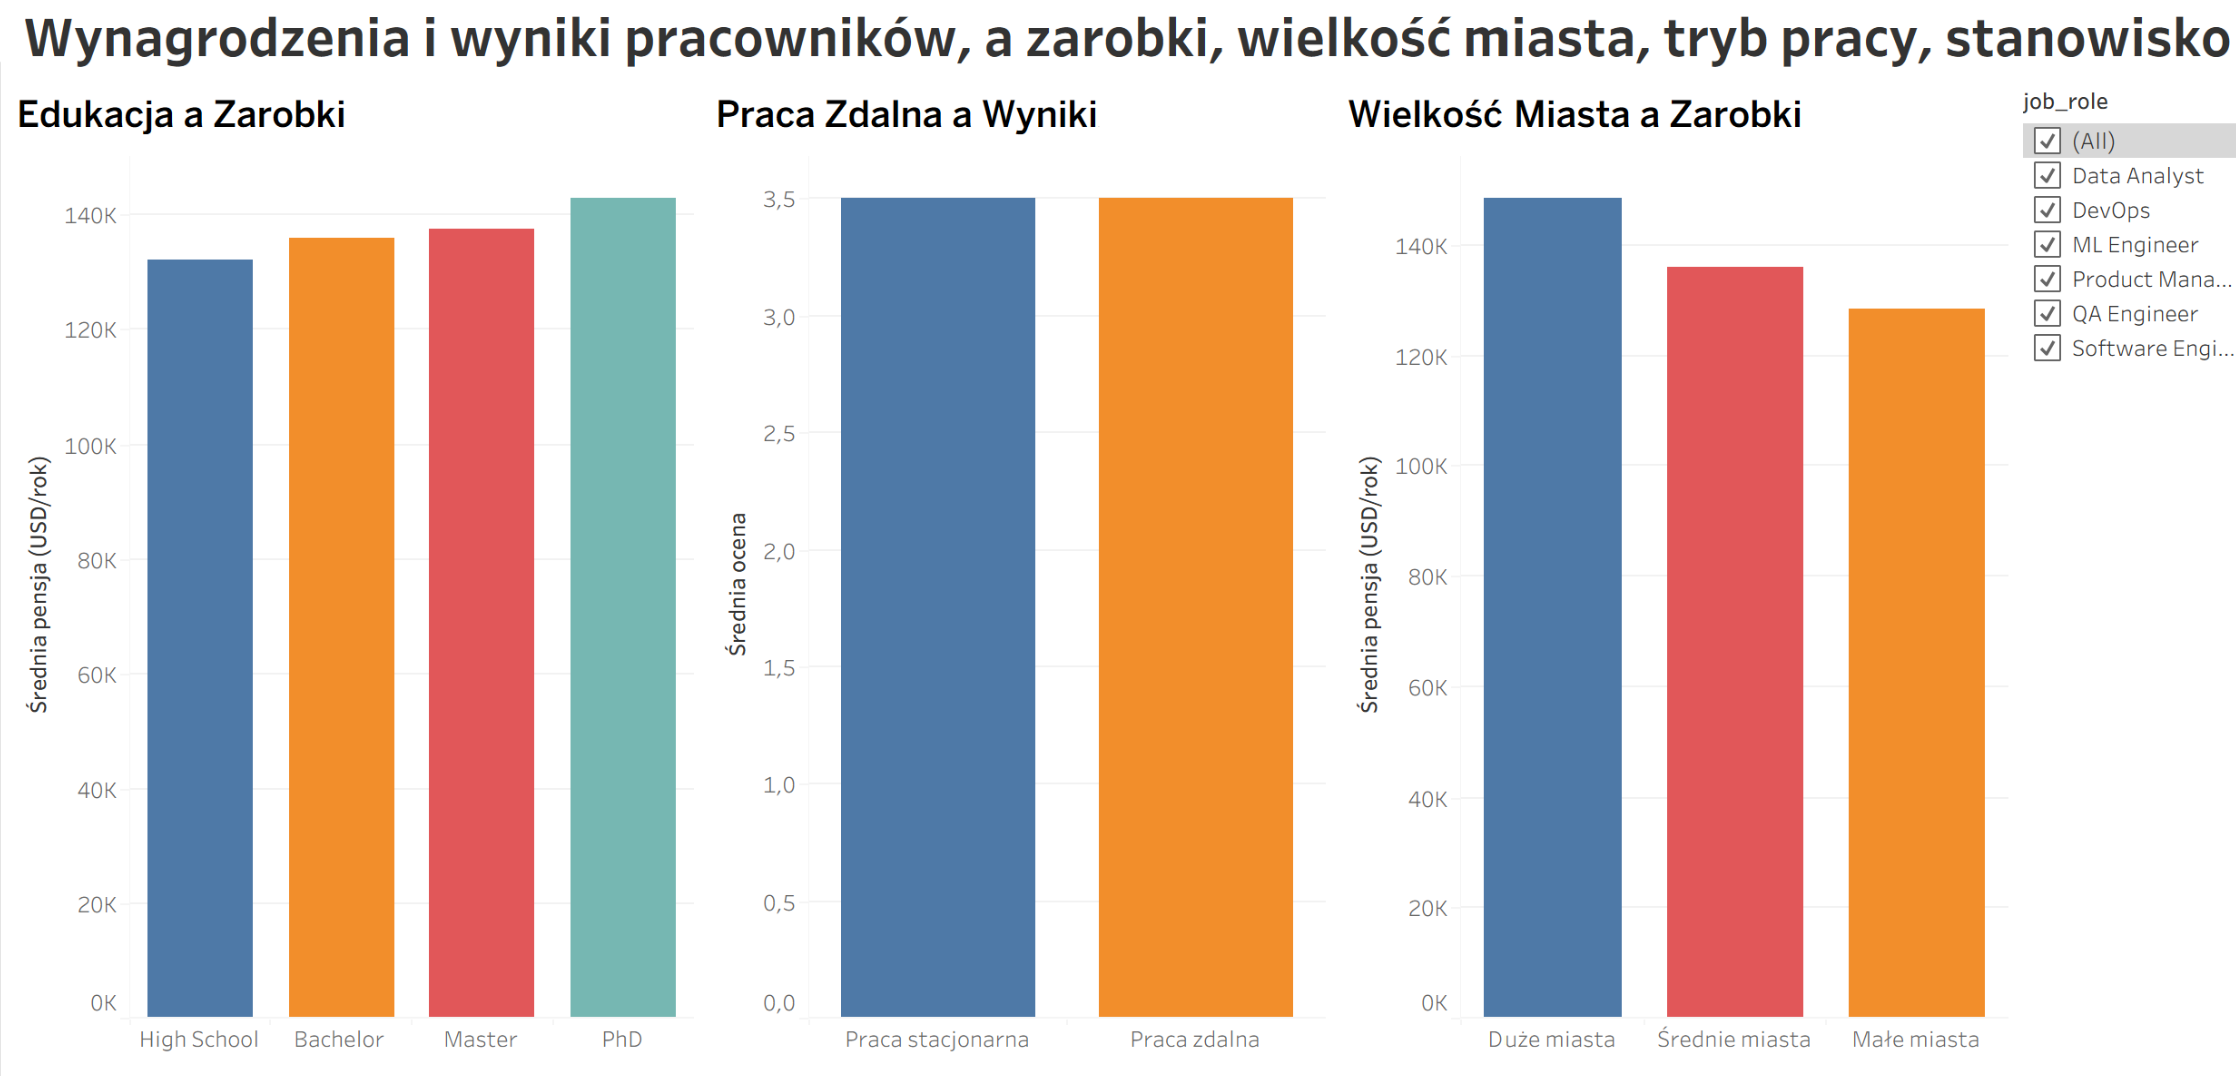